In [1]:
import pandas as pd
import numpy as np
import os, glob
import re
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [ ]:
# df.drop(columns=['solute'], inplace=True)
mlip_list = df.columns.tolist()
remove_list = ['DFT','model']
for r in remove_list:
    mlip_list.remove(r)

delta_df = pd.DataFrame()
print(delta_df)
# delta_df['config'] = df['model']    
for mlip in mlip_list:
    df[mlip+'_delta'] = df[mlip] - df['DFT']
    delta_df[mlip] = df[mlip]-df['DFT']
delta_df.to_csv('/Users/yujinkang/delta_E_bind.csv', index=False)
# df.reset_index(inplace=True)
delta_df

: 

In [43]:
error_df = pd.DataFrame()
for mlip in mlip_list:
    error_df.loc['MAE',mlip] = abs_df[mlip].mean()
error_df.to_csv('/Users/yujinkang/mae_E_bind.csv')

In [33]:
abs_err = df[mlip_list].sub(df['DFT'], axis=0).abs()
abs_err
mae = abs_err.mean()
mae
n_used = abs_err.count()
n_used
coverage = (n_used / len(df)).rename("coverage")
summary = pd.concat([mae.rename("MAE"), n_used.rename("N_used"), coverage], axis=1).sort_values("MAE")
summary.to_csv('/Users/yujinkang/summary_E_bind.csv')

In [25]:
abs_df = delta_df.abs()
abs_df.to_csv('/Users/yujinkang/abs_delta_E_bind.csv', index=False)

In [13]:
sns_df = pd.DataFrame(columns=['index','DFT', 'mlip', 'pred','delta','abs_error'], index=range(len(mlip_list)*len(df)))
idx = 0
for i in range(len(df)):
    for mlip in mlip_list:
        sns_df.loc[idx, 'index'] = i
        sns_df.loc[idx, 'DFT'] = df.loc[i, 'DFT']
        sns_df.loc[idx, 'mlip'] =  mlip
        sns_df.loc[idx, 'pred'] = df.loc[i, mlip]
        sns_df.loc[idx, 'delta'] = df.loc[i, mlip+'_delta']
        sns_df.loc[idx, 'abs_error'] = abs(df.loc[i, mlip+'_delta'])
        idx += 1
sns_df.to_csv('/Users/yujinkang/sns.csv', index=False)

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 5

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.18
plt.rcParams['figure.subplot.left'] = 0.1
plt.rcParams['figure.subplot.right'] = 0.97
plt.rcParams['figure.subplot.top'] = 0.98
plt.rcParams['figure.subplot.wspace'] = 0.03
plt.rcParams['figure.subplot.hspace'] = 0.03



In [8]:

color_dict= {
    'ompa-omat': '#02baae',
    'ompa-mpa': '#72b8b3',
    'omni-omat': '#0073ff',
    'omni-mpa': '#8cbbf5',
    'omni-matpes_pbe': '#0047b3',
    'ORB-omat': '#d48f3f',
    'ORB-mpa': '#d9ba98',
    'eSEN-omat':'#e8d803',
    'eSEN-oam': '#f5ea74',
    'DPA-mp': '#d19adf',
    'DPA-omat': '#e829f6',
    'UMA-omat': '#ff0000',
    'UMA-omc': '#ff7f7f',
    'MACE-omat': '#00b300',
    'MACE-mpa': '#66ff66',
    'grace-omat': '#8b4513',
    'grace-oam': '#deb887',
    'nequip-oam': '#a52a2a',
}

solute_color_dict = {
    'Co': '#95bcff',
    'Cr': '#efa366',
    'Cu': '#03bc25',
    'Mn': '#ffa9ec',
    'Mo': '#b1ffba',
    'Nb': '#adadad',
    'Ni': '#e2e2e2',
    'Ti': '#00d4df',
    'V': '#fee900',
}

In [31]:

carbon_mae = carbon_df.loc['MAE'].values
tm_mae = tm_df.loc['MAE'].values
tot_mae = tot_df.loc['MAE'].values
carbon = pd.DataFrame()
carbon['mlip'] = carbon_df.keys().tolist()
tm = pd.DataFrame()
tm['mlip'] = tm_df.keys().tolist()
tot = pd.DataFrame()
tot['mlip'] = tot_df.keys().tolist()
carbon['MAE'] = carbon_mae
tm['MAE'] = tm_mae
tot['MAE'] = tot_mae
 
carbon.to_csv('../carbon/sns_mae.csv', index=False)
tm.to_csv('../tm/sns_mae.csv', index=False)
tot.to_csv('../tot/sns_mae.csv', index=False)

In [35]:
carbon = pd.read_csv('../carbon/sns_mae.csv')
tm = pd.read_csv('../tm/sns_mae.csv')
tot = pd.read_csv('../tot/sns_mae.csv')
carbon =carbon.drop(carbon[carbon['mlip']=='UMA-omc'].index)
tm =tm.drop(tm[tm['mlip']=='UMA-omc'].index)
tot =tot.drop(tot[tot['mlip']=='UMA-omc'].index)

/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_2671/3152433510.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


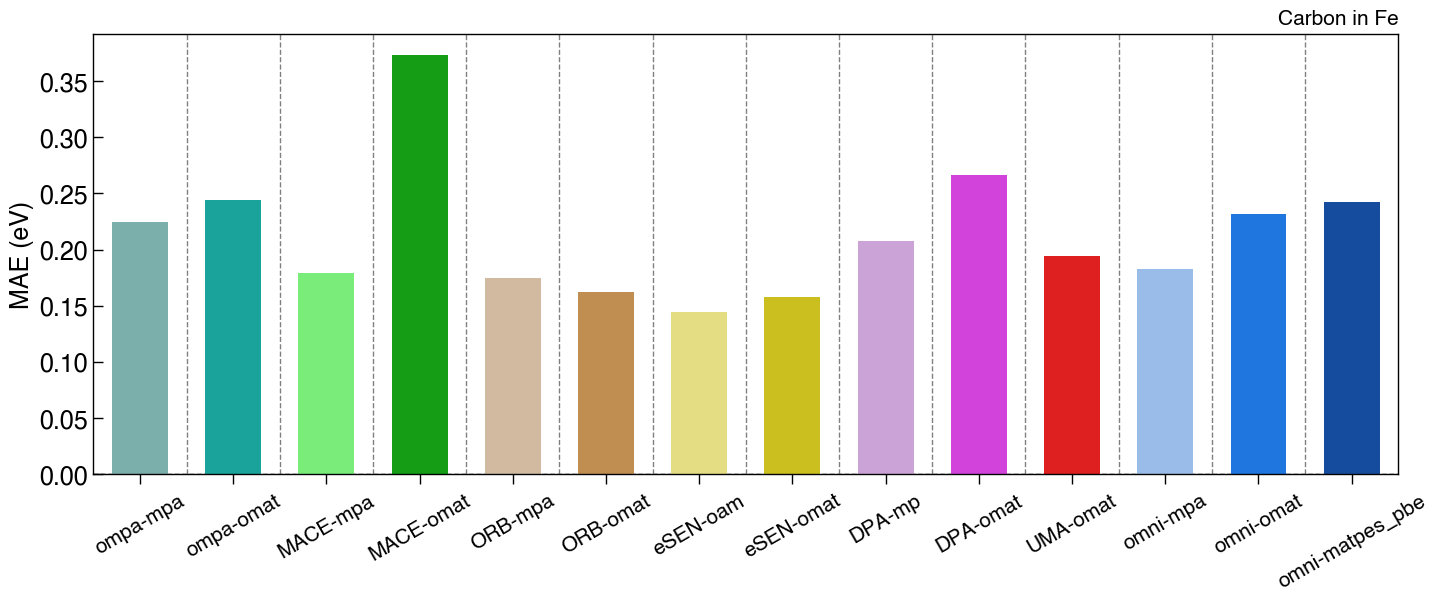

In [49]:
plt.figure(figsize=(15,5.5))
vlines = [i+0.5 for i in range(len(carbon)-1)]
mlip_list = carbon['mlip']
sns.barplot(
    data=carbon, 
    x="mlip", 
    y="MAE", 
    width = 0.6,
    palette=color_dict,   # pick any color scheme
    errorbar=None        # removes those ugly error bars
)
plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
plt.title(r"Carbon in Fe")
plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
for v in vlines:
    plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
plt.ylabel(r"MAE (eV)")
plt.xlabel("")

plt.tick_params(axis="x", which="major", pad=5)
filename = 'fig_mae_carbon.png'
plt.savefig(filename, transparent=True)

plt.show()


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_2671/2095975151.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


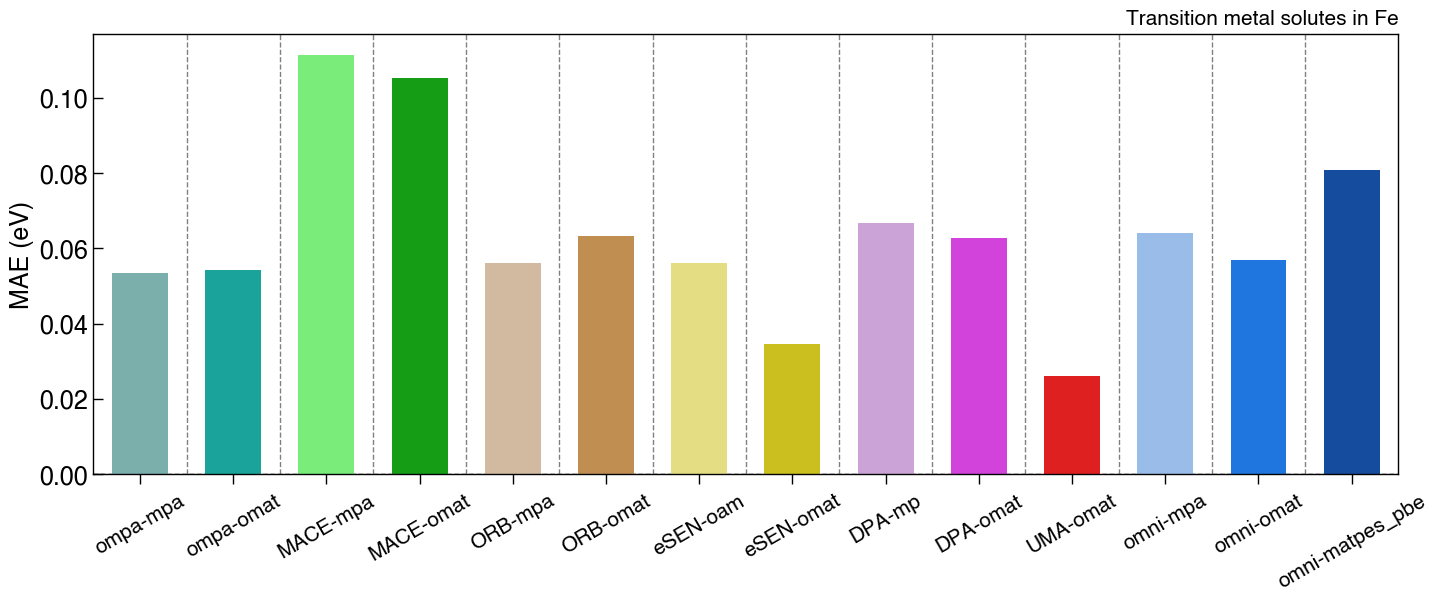

In [54]:
plt.figure(figsize=(15,5.5))
vlines = [i+0.5 for i in range(len(tm)-1)]
mlip_list = tm['mlip']
sns.barplot(
    data=tm, 
    x="mlip", 
    y="MAE", 
    width = 0.6,
    palette=color_dict,   # pick any color scheme
    errorbar=None        # removes those ugly error bars
)
plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
plt.title(r"Transition metal solutes in Fe")
plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
for v in vlines:
    plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
plt.ylabel(r"MAE (eV)")
plt.xlabel("")

plt.tick_params(axis="x", which="major", pad=5)
filename = 'fig_mae_tm.png'
plt.savefig(filename, transparent=True)

plt.show()


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_2671/1192494557.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


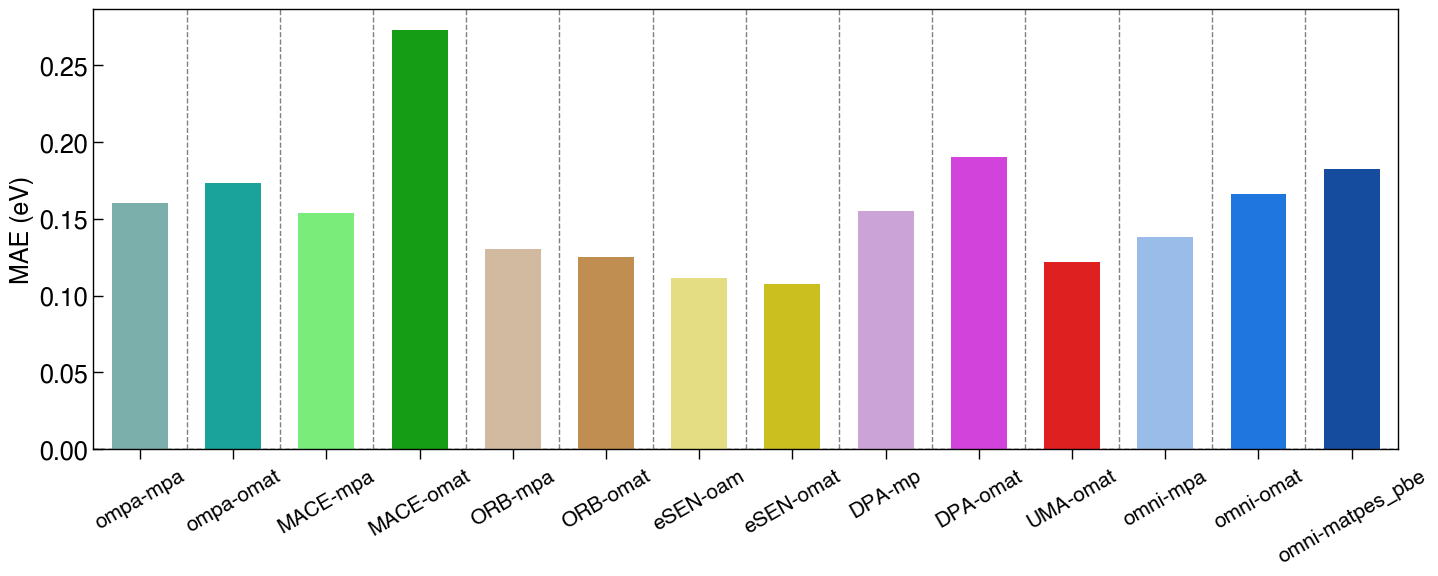

In [55]:
plt.figure(figsize=(15,5.5))
vlines = [i+0.5 for i in range(len(tm)-1)]
mlip_list = tot['mlip']
sns.barplot(
    data=tot, 
    x="mlip", 
    y="MAE", 
    width = 0.6,
    palette=color_dict,   # pick any color scheme
    errorbar=None        # removes those ugly error bars
)
plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
# plt.title(r"Carbon in Fe")
plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
for v in vlines:
    plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
plt.ylabel(r"MAE (eV)")
plt.xlabel("")

plt.tick_params(axis="x", which="major", pad=5)
filename = 'fig_mae_tot.png'
plt.savefig(filename, transparent=True)

plt.show()


In [44]:
def plot_box(sns_df,filename):
    plt.figure(figsize=(15,6.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]
    sns.boxplot(
        data=sns_df,
        x="mlip",
        y="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.6
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
        
    plt.tick_params(axis="x", which="major", pad=5)
    plt.savefig(filename, transparent=True)
    # plt.close()
    plt.show()
    print(f'Box plot saved as {filename}')


In [52]:
def plot_violin(sns_df, filename):
    plt.figure(figsize=(15,5.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]

    sns.violinplot(
        data=sns_df,
        x="mlip",
        y="delta",          
        inner="quartile",
        cut=0,
        palette=color_dict
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
    
    # sns.despine()
    
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tight_layout()
    plt.savefig(filename, transparent=True)
    plt.show()

    print(f'Violin plot saved as {filename}')


In [16]:

solutes= ['Co', 'Cr', 'Cu', 'Mn', 'Mo', 'Nb', 'Ni', 'Ti', 'V']

df = pd.read_csv('./E_bind_tm_250916.csv')

dft = df['DFT'].tolist()

df.columns.tolist()

mlip_list = df.columns.tolist()
remove_list = ['DFT','config']
for r in remove_list:
    mlip_list.remove(r)

In [18]:
mlip_list

['ompa-mpa',
 'ompa-omat',
 'MACE-mpa',
 'MACE-omat',
 'ORB-mpa',
 'ORB-omat',
 'eSEN-oam',
 'eSEN-omat',
 'DPA-mp',
 'DPA-omat',
 'UMA-omc',
 'UMA-omat',
 'omni-mpa',
 'omni-omat',
 'omni-matpes_pbe',
 'grace-omat',
 'grace-oam',
 'nequip-oam']

ompa-mpa
ompa-omat
MACE-mpa
MACE-omat
ORB-mpa
ORB-omat
eSEN-oam
eSEN-omat
DPA-mp
DPA-omat
UMA-omc
UMA-omat
omni-mpa
omni-omat
omni-matpes_pbe


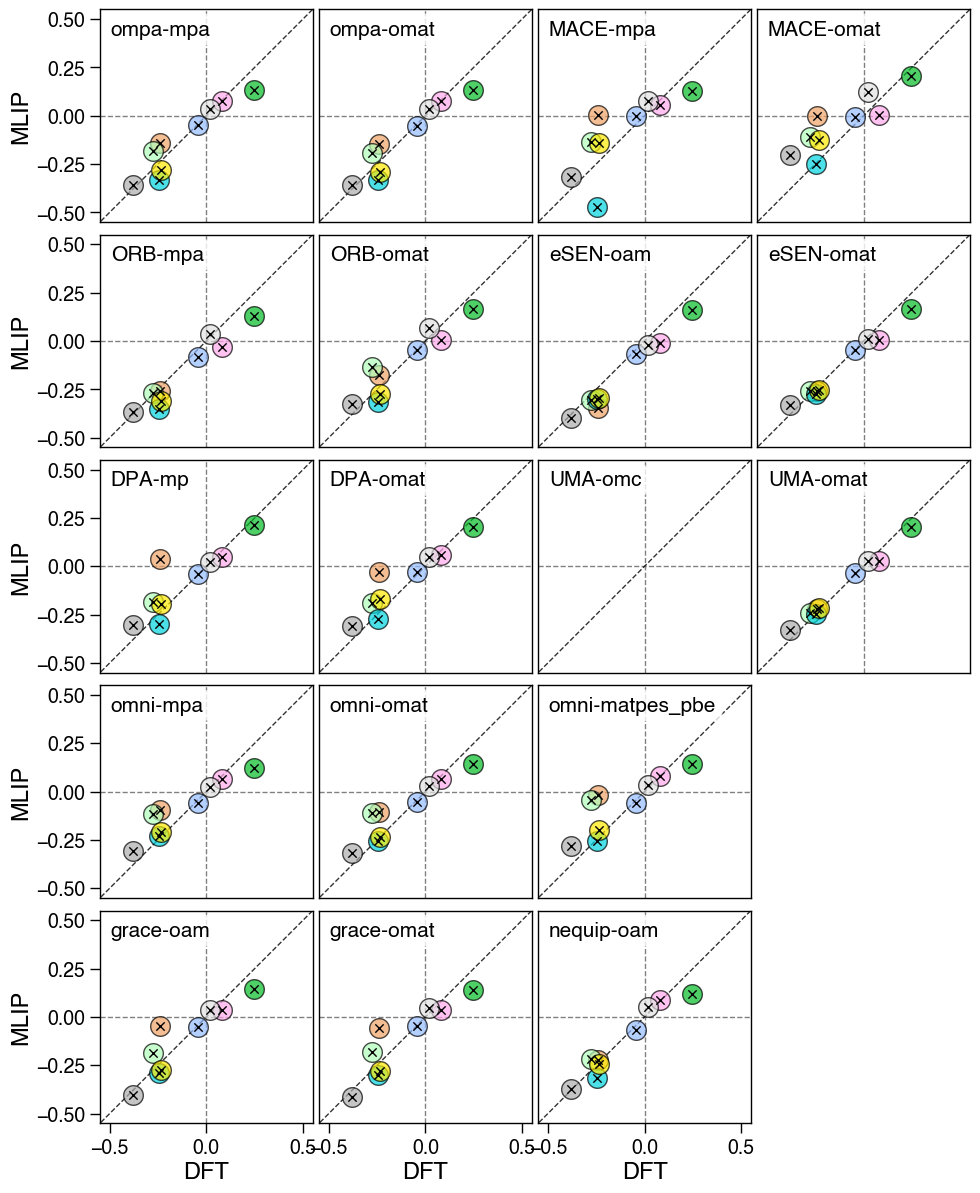

In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

models = [
    "ompa-mpa", "ompa-omat", "MACE-mpa","MACE-omat",
    "ORB-mpa","ORB-omat","eSEN-oam","eSEN-omat",
    "DPA-mp","DPA-omat","UMA-omc","UMA-omat",
    "omni-mpa","omni-omat","omni-matpes_pbe",
    "grace-oam","grace-omat", "nequip-oam"
]


fig = plt.figure(figsize=(10,14))
# 3 main rows (4 models each), plus 1 row for grace
gs = gridspec.GridSpec(5, 4, figure=fig)
lims = [-0.55, 0.55]

# First 12 models in top 3 rows
for i, m in enumerate(models[:-3]):
    print(m)
    row, col = divmod(i, 4)
    ax = fig.add_subplot(gs[row, col])
    mlip_values = df[m].tolist()
    ax.text(0.05, 0.95, m, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    ax.set_box_aspect(1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    for j, solute in enumerate(solutes):
        ax.scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=3)        
        ax.scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=200, edgecolors='k', linewidth=1, alpha=0.7, zorder=2)
        
    ax.plot([-0.6,0.6],[-0.6,0.6],"k--",lw=1, zorder=1, alpha=0.8)
    ax.set_xticks([]);
    if i % 4 == 0:
        ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
    else:
        ax.set_yticks([])

# Last two models on their own row
for k, m in enumerate(models[-3:]):
    ax = fig.add_subplot(gs[4, k])
    mlip_values = df[m].tolist()
    ax.text(0.05, 0.95, m, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    ax.set_box_aspect(1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    for j, solute in enumerate(solutes):
        ax.scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=3)        
        ax.scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=200, edgecolors='k', linewidth=1, alpha=0.7, zorder=2)
    ax.plot([-0.6,0.6],[-0.6,0.6],"k--",lw=1, zorder=1, alpha=0.8)
    ax.set_xlabel("DFT", fontsize=17, labelpad=3)

    if k == 0:
        ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
    else:
        ax.set_yticks([])
    

plt.savefig('tm_el.png', dpi=300, bbox_inches='tight', transparent=True)


# plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

models = [
    "ompa-mpa", "ompa-omat", "MACE-mpa","MACE-omat",
    "ORB-mpa","ORB-omat","eSEN-oam","eSEN-omat",
    "DPA-mp","DPA-omat","UMA-omc","UMA-omat",
    "omni-mpa","omni-omat","omni-matpes_pbe",
    "grace-oam","grace-omat", "nequip-oam"
]


fig = plt.figure(figsize=(10,14))
# 3 main rows (4 models each), plus 1 row for grace
gs = gridspec.GridSpec(5, 4, figure=fig)
lims = [-0.55, 0.55]

# First 12 models in top 3 rows
for i, m in enumerate(models[:-3]):
    print(m)
    row, col = divmod(i, 4)
    ax = fig.add_subplot(gs[row, col])
    mlip_values = df[m].tolist()
    ax.text(0.05, 0.95, m, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    ax.set_box_aspect(1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    for j, solute in enumerate(solutes):
        ax.scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=3)        
        ax.scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=200, edgecolors='k', linewidth=1, alpha=0.7, zorder=2)
        
    ax.plot([-0.6,0.6],[-0.6,0.6],"k--",lw=1, zorder=1, alpha=0.8)
    ax.set_xticks([]);
    if i % 4 == 0:
        ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
    else:
        ax.set_yticks([])

# Last two models on their own row
for k, m in enumerate(models[-3:]):
    ax = fig.add_subplot(gs[4, k])
    mlip_values = df[m].tolist()
    ax.text(0.05, 0.95, m, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    ax.set_box_aspect(1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1, zorder=0)
    for j, solute in enumerate(solutes):
        ax.scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=3)        
        ax.scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=200, edgecolors='k', linewidth=1, alpha=0.7, zorder=2)
    ax.plot([-0.6,0.6],[-0.6,0.6],"k--",lw=1, zorder=1, alpha=0.8)
    ax.set_xlabel("DFT", fontsize=17, labelpad=3)

    if k == 0:
        ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
    else:
        ax.set_yticks([])
    

# plt.savefig('tm_el.png', dpi=300, bbox_inches='tight', transparent=True)


# plt.tight_layout()
plt.show()

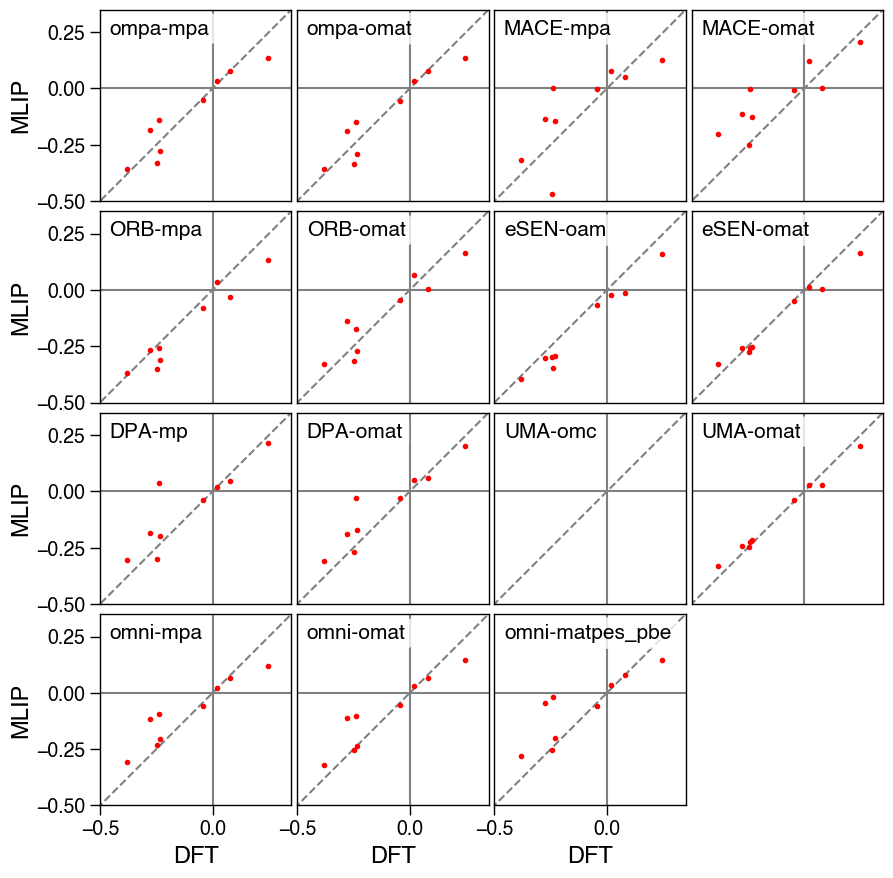

In [246]:
lims = [-0.5, 0.35]
fig, axes = plt.subplots(4,4, figsize=(9,10), sharex=True, sharey=True)
for i, (ax, mlip) in enumerate(zip(axes.flatten(), mlip_list)):
    if i < len(mlip_list):
        ax.plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1.5, zorder=0)
        ax.scatter(df['DFT'], df[mlip], color='red', marker='.', alpha=1)
        ax.axhline(0, color='grey', linestyle='-', linewidth=1.5, zorder=0)
        ax.axvline(0, color='grey', linestyle='-', linewidth=1.5, zorder=0)
        # ax.set_title(mlip)
        ax.set_box_aspect(1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.text(0.05, 0.95, mlip, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
        if i % 4 == 0:
            ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
        else:
            ax.get_yaxis().set_visible(False)
        if i < 12:
            ax.get_xaxis().set_visible(False)
        else:
            ax.set_xlabel("DFT", fontsize=17, labelpad=5)


        
        # ax.set_xticks(rotation=90)
        # ax.set_ylabel("MLIP")
        # ax.set_xlabel('DFT')
    else:
        # continue
        ax.axis('off')
for ax in axes.flatten()[len(mlip_list):]:
    ax.axis("off")
# fig.tight_layout()

plt.savefig('quick_scatter.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()
